# 📗 02. 데이터 EDA — H&M 커머스 탐색적 분석

> 엔코아 AI캠퍼스 · 데이터 분석 & AI 머신러닝 캠프

이 노트북은 **01_데이터이해_전처리**가 만든 정제본으로 **탐색적 데이터 분석(EDA)** 을 합니다. day07(EDA·시각화) 전체와 day08(기술통계)을 이 파트에서 다룹니다 — **추론통계(가설검정·회귀)는 03_데이터_통계**에서 이어집니다.

**이 노트북 읽는 법**
- 각 절 시작에 **"이 절에서 할 일"** 한 줄이 있습니다.
- 이 노트북에는 **완성된 코드가 없습니다.** 각 절이 **무엇을 만들어야 하는지**와 **어떤 도구(함수·핵심 인자)를 쓰는지**를 알려 주니, **코드는 그것을 보고 스스로 쓰세요.**
- 막히면 **"막히면 볼 곳"** 이 가리키는 **day07·day08 교안**에서 필요한 함수를 찾아 쓰세요.
- 각 절 끝에 **"여기까지 되면 통과"** 로 스스로 확인하세요(자가채점 없음).
- **2절(필수 미션)은 반드시**, **3절(선택 카탈로그)은 원하는 것만** — 이 둘은 성격이 다르니 헷갈리지 마세요.

**목차**
1. 정제본 불러오기
2. 필수 EDA 미션 (반드시)
3. 선택 EDA 미션 카탈로그 (골라서)
4. 관찰 정리 (서술)

## 1. 정제본 불러오기
**이 절에서 할 일**: 01 이 저장한 정제본(`output/hm_clean.csv`)을 **직접 불러와**, 이후 모든 절에서 이어 쓸 `df` 와 표본 `df_s`, 파생변수 세 개를 준비합니다.

> ⚠️ **01 을 먼저 끝내야 합니다.** 이 노트북은 01 의 마지막 셀이 저장한 정제본에서 시작합니다. `output/hm_clean.csv` 가 없으면 01 로 돌아가 저장 셀까지 실행하고 오세요. 원본 3개 테이블을 여기서 다시 읽지는 않습니다.

**이 노트북이 쓰는 컬럼** — 01 의 정제본에 아래가 남아 있어야 뒤 절의 지침을 그대로 따를 수 있습니다: `t_dat`·`customer_id`·`article_id`·`price`·`age`·`sales_channel_id`·`club_member_status`·`fashion_news_frequency`·`product_group_name`·`prod_name`·`index_group_name`. 빠진 것이 있으면 01 에서 그 컬럼을 남긴 채 다시 저장하세요.

> 🔧 01 에서 여러분이 고른 처리 규칙(연령 범위·0원 거래·채널 코드·멤버십 결측)이 그대로 반영되므로, 아래 지침의 "이렇게 나오면 맞다"와 **행수·수치가 조금 달라도 정상**입니다.

**1-1. 준비 — 라이브러리와 한글 폰트**

- **무엇을 만드나**: 이 노트북에서 쓸 라이브러리를 한 셀에 모아 불러오고, 그래프의 한글이 깨지지 않게 폰트를 설정합니다.
- **왜**: matplotlib 의 기본 폰트에는 한글 글자가 없어서, 폰트를 지정하지 않으면 그래프의 모든 한글이 네모(□)로 나옵니다.
- **이렇게 나오면 맞다**: 에러 없이 셀이 끝나고, 뒤에서 그린 그래프의 한글 제목이 네모(□) 없이 보입니다.
- **함정**: `sns.set_theme()` 은 `font.family` 를 자기 기본값으로 **되돌립니다** — 폰트를 먼저 지정하고 그 뒤에 `set_theme()` 을 부르면 한글이 다시 깨집니다. 순서를 바꾸거나 `set_theme(font=…)` 로 함께 넘기세요.

In [87]:
# ── 쓸 도구 ─────────────────────────────────────────
#   pandas(pd)·numpy(np)·matplotlib.pyplot(plt)·seaborn(sns) — 별칭은 이 관례 그대로
#     쓰세요(뒤 절 지침이 이 이름으로 설명합니다).
#   from scipy import stats — 절사평균·왜도·첨도에서 씁니다.
#   한글 폰트: platform.system() 으로 OS 를 확인해 Windows 는 'Malgun Gothic',
#     macOS('Darwin')는 'AppleGothic', 그 외(Colab 등)는 'NanumGothic' 을
#     plt.rcParams['font.family'] 에 넣습니다.
#   음수 눈금이 네모로 깨지지 않게 plt.rcParams['axes.unicode_minus'] = False.
#   seaborn 테마를 쓰려면 sns.set_theme(style=…, font=…, rc={'axes.unicode_minus': False})
#     처럼 폰트를 함께 넘깁니다.
#   경고 문구가 시끄러우면 warnings.filterwarnings('ignore').

# 여기에 코드를 작성하세요
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import platform
import warnings

pd.set_option('display.max_columns', 40)

# 한글 폰트 — 실행 중인 OS 에 맞춰 자동 설정
if platform.system() == 'Windows':
    KOREAN_FONT = 'Malgun Gothic'
    FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
elif platform.system() == 'Darwin':          # macOS
    KOREAN_FONT = 'AppleGothic'
    FONT_PATH = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:                                        # Linux (Colab 등)
    KOREAN_FONT = 'NanumGothic'
    FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False   # 마이너스(−) 부호 깨짐 방지
sns.set_theme(font=KOREAN_FONT, rc={'axes.unicode_minus': False})

**1-2. 정제본 불러와 `df` 만들기**

- **무엇을 만드나**: 정제본 CSV(`output/hm_clean.csv`)를 읽어 **`df`** 라는 이름으로 두고, 날짜 컬럼 `t_dat` 을 날짜형으로 되돌린 뒤 **데이터를 먼저 훑습니다** — 모양·앞부분·자료형·요약 순서로.
- **왜**: 이 노트북의 모든 절이 **`df`** 라는 이름을 쓴다고 가정합니다. 이름을 다르게 두면 뒤 절의 지침을 그대로 따를 수 없습니다.
- **이렇게 나오면 맞다**: `df.shape` 가 (10만 행 안팎, 30여 컬럼)처럼 찍히고 head·info·describe 표가 보이며, `df['t_dat'].dtype` 이 `datetime64[ns]` 입니다.
- **함정**: CSV 로 저장했다가 다시 읽으면 **날짜형이 문자열로 풀립니다.** 변환을 빠뜨리면 뒤에서 `.dt.month` 를 쓸 때 `Can only use .dt accessor with datetimelike values` 에러가 납니다.

In [88]:
# ── 쓸 도구 ─────────────────────────────────────────
#   읽기: pd.read_csv(<경로>) — 경로는 위의 정제본 경로 그대로.
#   날짜형 변환: pd.to_datetime(<컬럼>) 의 결과를 같은 컬럼에 다시 넣습니다.
#   훑기 4종: 모양 df.shape -> 앞부분 display(df.head(3)) -> 열·자료형·결측 df.info() -> 수치
#     요약 df.describe() (DataFrame 은 print 보다 display 가 표로 예쁘게 나옵니다).
#   범주형 열은 df.describe() 에 안 나옵니다 — df.describe(exclude='number') 로 개수·고유값
#     수·최빈값을 봅니다.

# 여기에 코드를 작성하세요
df = pd.read_csv('output/hm_clean.csv')
# display(pd.to_datetime(df['t_dat'], errors='coerce'))
df['t_dat'] = pd.to_datetime(df['t_dat'], errors='coerce') # 날짜형 변환
display(df.shape)
display(df.head(3))
display(df.info())
display(df.describe(exclude='number'))

(116434, 37)

,t_dat,customer_id,article_id,price,sales_channel_id,FN,Active,club_member_status,fashion_news_frequency,age,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc,month,weekday,age_group
0,2019-01-01,80d8c96835c3aaf25a5b2bc306d9747bbd4601fd75bc65...,542677002,0.050831,2,0,0,ACTIVE,NONE,30,542677,Stetson SP Body Andes,283,Underwear body,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1338,Expressive Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Body in lace and mesh with underwired, thickly...",1,Tuesday,30
1,2019-01-01,a105c61ed98470b3dbed27f1bdfc584d09d20762efe680...,665201002,0.010153,2,1,1,ACTIVE,Regularly,21,665201,RA shorts conscious,274,Shorts,Garment Lower body,1010016,Solid,63,Dark Purple,4,Dark,6,Lilac Purple,8310,Ladies Sport Bottoms,S,Sport,26,Sport,5,Ladies H&M Sport,1005,Jersey Fancy,Short sports shorts in fast-drying functional ...,1,Tuesday,20
2,2019-01-01,05e0e58672ee73b047e510dbf974ce1870f92b71f5f6ac...,629061002,0.089983,2,0,0,ACTIVE,NONE,35,629061,Rachel jumper,252,Sweater,Garment Upper body,1010010,Melange,7,Grey,2,Medium Dusty,12,Grey,1612,Jersey/Knitwear Premium,A,Ladieswear,1,Ladieswear,14,Womens Premium,1003,Knitwear,"Jumper in soft, fine-knit cashmere with long, ...",1,Tuesday,30


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116434 entries, 0 to 116433
Data columns (total 37 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   t_dat                         116434 non-null  datetime64[ns]
 1   customer_id                   116434 non-null  object        
 2   article_id                    116434 non-null  int64         
 3   price                         116434 non-null  float64       
 4   sales_channel_id              116434 non-null  int64         
 5   FN                            116434 non-null  int64         
 6   Active                        116434 non-null  int64         
 7   club_member_status            113383 non-null  object        
 8   fashion_news_frequency        116434 non-null  object        
 9   age                           116434 non-null  int64         
 10  product_code                  116434 non-null  int64         
 11  prod_name    

None

,t_dat,customer_id,club_member_status,fashion_news_frequency,prod_name,product_type_name,product_group_name,graphical_appearance_name,colour_group_name,perceived_colour_value_name,perceived_colour_master_name,department_name,index_code,index_name,index_group_name,section_name,garment_group_name,detail_desc,weekday
count,116434,116434,113383,116434,116434,116434,116434,116434,116434,116434,116434,116434,116434,116434,116434,116434,116434,115942,116434
unique,NaN,95516,3,3,14906,108,15,29,50,8,19,232,10,10,5,55,21,13910,7
top,NaN,06d23b72cac134851a761473b40c881c300814981b6b0a...,ACTIVE,NONE,Jade HW Skinny Denim TRS,Trousers,Garment Upper body,Solid,Black,Dark,Black,Swimwear,A,Ladieswear,Ladieswear,Womens Everyday Collection,Jersey Fancy,High-waisted jeans in washed superstretch deni...,Saturday
freq,NaN,11,111065,65859,647,15011,46183,63554,40463,58753,39890,9626,48173,48173,75369,22280,18745,801,18086
mean,2019-06-27 09:19:57.856296448,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2019-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2019-04-09 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2019-06-25 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2019-09-16 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2019-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> ⚠️ **발제문 설명과 데이터가 다르면, 옳은 것은 데이터입니다.** 발제문 참고사항에는 `price` 가 **"SEK(스웨덴 크로나)"** 이고 기간이 **"수년간"** 이라고 적혀 있습니다. 직접 확인해 보세요 — `df['price'].min()`·`max()` 와 `df['t_dat'].min()`·`max()` 를 찍어 보면, `price` 는 0 과 1 사이의 **정규화된 상대값**이고 기간은 **1년**입니다. 그래서 이 프로젝트는 price 를 금액이 아니라 **상대값**으로만 다루고("몇 크로나"가 아니라 "어느 쪽이 몇 배"), **"연도별 추세"는 이 데이터로 말하지 않습니다.** 남이 써 준 설명을 데이터로 검증하는 것도 분석가의 일입니다.

**파생변수 만들기 — 이후 절에서 쓸 `month`·`weekday`·`age_group`**
정제본에 이미 있어도 여기서 다시 확인해 둡니다. 이후 EDA·기술통계에서 계속 쓸 파생변수 세 개입니다(day07 파생변수 레시피 — 날짜 분해·구간화). 이 노트북의 나머지 절은 전부 이 파생변수가 있다고 가정합니다.

**1-3. 파생변수 3개와 표본 1개**

- **무엇을 만드나**: `df` 에 컬럼 세 개를 **이 이름 그대로** 추가하고, 무거운 그림·집계에 재사용할 표본 `df_s` 를 만듭니다. `month` = 거래일의 월(1~12 정수), `weekday` = 거래일의 요일 이름(Monday…), `age_group` = 나이를 10살 단위로 내림한 정수(23세 → 20), `df_s` = 3,000행 무작위 표본.
- **왜**: **이 노트북의 뒤 절과 03_데이터_통계가 이 컬럼 이름을 그대로 씁니다.** `달`·`요일`·`나이대` 처럼 다른 이름으로 만들면 뒤의 지침과 03 이 그 컬럼을 찾지 못합니다.
- **이렇게 나오면 맞다**: `df[['month', 'weekday', 'age_group']].head()` 에 1~12 정수·영어 요일 이름·10 단위 정수가 보이고, `len(df_s)` 가 3000 입니다.
- **함정**: `.dt` 는 **날짜형 컬럼에만** 붙습니다(1-2 에서 변환했는지 확인). `age_group` 을 정수로 바꾸지 않으면 20.0 처럼 소수로 찍혀 그래프 눈금이 지저분해집니다.

In [170]:
# ── 쓸 도구 ─────────────────────────────────────────
#   월·요일: 날짜형 컬럼의 .dt 접근자 — .dt.month, .dt.day_name().
#   연령대: 정수 나눗셈으로 10 단위로 내린 뒤(나이 // 10 * 10 꼴) .astype(int) 로 정수화.
#   표본: df.sample(n=…, random_state=42) — random_state 를 고정해야 매번 같은 표본이 나와
#     결과를 비교할 수 있습니다.

# 여기에 코드를 작성하세요
display(df[['month', 'weekday', 'age_group']].info())
df_s = df.sample(n=3000, random_state=42)
display(df_s[['month','weekday', 'age_group']].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116434 entries, 0 to 116433
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   month      116434 non-null  int64 
 1   weekday    116434 non-null  object
 2   age_group  116434 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.7+ MB


None

,month,weekday,age_group
103572,11,Saturday,40
49578,6,Wednesday,20
66589,7,Saturday,30
97828,10,Tuesday,20
101479,11,Wednesday,20


**짚고 넘어가기 — merge 후 행이 늘지 않았는지 검증**
01 에서 거래·고객·상품을 merge 할 때 다대다(many-to-many) 매칭이 있으면 행이 **예상보다 훨씬 많이** 늘어납니다(뻥튀기). 지금 정제본을 받았어도, 습관적으로 **거래를 유일하게 식별하는 조합**(고객·상품·날짜)에 중복이 없는지 한 번 더 확인하세요.

**1-4. 중복 검증**

- **무엇을 만드나**: `customer_id`·`article_id`·`t_dat` 세 컬럼을 묶었을 때 중복이 몇 건인지 세어, 전체 행수와 함께 한 줄로 출력합니다.
- **이렇게 나오면 맞다**: "중복 N건 / 전체 M행" 이 찍히고, N 이 전체(11만여 행)에 비해 **수십 건 이하**로 아주 작습니다.
- **함정**: `subset` 을 빼면 **모든 컬럼이 같은 행**만 세므로 거래 중복을 못 잡습니다. `.sum()` 대신 `.count()` 를 쓰면 True 개수가 아니라 전체 행수가 나옵니다.

In [90]:
# ── 쓸 도구 ─────────────────────────────────────────
#   중복 여부: df.duplicated(subset=[<컬럼 목록>]) — 행마다 True/False 를 돌려줍니다.
#   건수: 그 결과에 .sum() (True 가 1 로 더해집니다).
#   전체 행수: len(df).

# 여기에 코드를 작성하세요
print('customer_id, article_id, t_dat 중복 건수 : ', df[['customer_id', 'article_id', 't_dat']].duplicated(subset=['customer_id', 'article_id', 't_dat']).sum(),'건')
print(f'전체 건수 : {len(df):,} 건')

customer_id, article_id, t_dat 중복 건수 :  14 건
전체 건수 : 116,434 건


> ⚠️ 0 이 아니어도 바로 오류는 아닙니다 — 같은 고객이 같은 날 같은 상품을 **여러 번** 사면 똑같은 조합이 나올 수 있습니다(수량 컬럼이 없을 때). 이 정제본은 그 비율이 전체 대비 매우 작습니다 — **비율이 크다면** merge 방식(다대다 매칭 여부)을 의심하세요.

> ✅ **여기까지 되면 통과**: `df.shape` 가 출력되고 위 `head()` 표가 정상적으로 보이면 됩니다(정확한 행수는 01 에서 고른 규칙에 따라 달라질 수 있습니다).

## 2. 필수 EDA 미션
> ⚠️ **이 절은 필수입니다.** 발제문의 필수 분석 목표 중 이 파트가 맡은 두 가지입니다. **자가채점은 없습니다** — 체크포인트로 스스로 확인하세요.

### 필수 미션 1 — 기술통계 제시
정제본의 **컬럼 타입·결측**과, 주요 수치 컬럼(`price`·`age` 등)의 **대표값**(평균·중앙값 등)과 **산포**(표준편차 등)를 표로 제시하세요. 대표값·산포 함수는 day08 교안에서 찾아 쓰세요.

> 🔧 **막히면 볼 곳**: day07·day08 교안 — 기술통계 도구(대표값·산포).

> ✅ **여기까지 되면 통과**: 수치형은 min/median/mean/max, 범주형은 value_counts 상위 몇 개가 나오면 됩니다 — 형식은 자유입니다.

In [91]:
# 여기에 코드를 작성하세요
display(df.describe())  # df 데이터프레임의 수치형 컬럼 요약
display(df.std(numeric_only=True, ddof=1))  # df 데이터프레임의 표준편차
display(df.var(numeric_only=True, ddof=1))  # df 데이터프레임의 분산


,t_dat,article_id,price,sales_channel_id,FN,Active,age,product_code,product_type_no,graphical_appearance_no,colour_group_code,perceived_colour_value_id,perceived_colour_master_id,department_no,index_group_no,section_no,garment_group_no,month,age_group
count,116434,1.164340e+05,116434.000000,116434.000000,116434.000000,116434.000000,116434.000000,116434.000000,116434.000000,1.164340e+05,116434.000000,116434.000000,116434.000000,116434.000000,116434.000000,116434.000000,116434.000000,116434.000000,116434.000000
mean,2019-06-27 09:19:57.856296448,6.742144e+08,0.027538,1.683529,0.433121,0.426783,39.248372,674214.390831,245.586160,1.009580e+06,26.319237,3.302781,7.656879,2841.640775,2.361063,36.647637,1010.782452,6.361733,34.857086
min,2019-01-01 00:00:00,1.087750e+08,0.000000,0.000000,0.000000,0.000000,0.000000,108775.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,-1.000000,1201.000000,1.000000,2.000000,1001.000000,1.000000,0.000000
25%,2019-04-09 00:00:00,6.284250e+08,0.015237,1.000000,0.000000,0.000000,25.000000,628425.000000,253.000000,1.010010e+06,9.000000,2.000000,5.000000,1612.000000,1.000000,15.000000,1005.000000,4.000000,20.000000
50%,2019-06-25 00:00:00,7.057340e+08,0.025407,2.000000,0.000000,0.000000,32.000000,705734.000000,264.000000,1.010016e+06,10.000000,4.000000,5.000000,1717.000000,1.000000,48.000000,1010.000000,6.000000,30.000000
75%,2019-09-16 00:00:00,7.501270e+08,0.033881,2.000000,1.000000,1.000000,48.000000,750127.000000,273.000000,1.010016e+06,42.000000,4.000000,11.000000,3937.000000,2.000000,60.000000,1017.000000,9.000000,40.000000
max,2019-12-31 00:00:00,8.779840e+08,0.422034,2.000000,1.000000,1.000000,999.000000,877984.000000,532.000000,1.010028e+06,93.000000,7.000000,20.000000,9989.000000,26.000000,97.000000,1025.000000,12.000000,990.000000
std,NaN,1.179016e+08,0.019324,0.476449,0.495509,0.494612,55.035117,117901.608254,67.660758,2.092577e+04,26.141316,1.413168,5.071244,2060.220148,4.678088,23.044759,6.584902,3.247355,54.851736


article_id                    1.179016e+08
price                         1.932387e-02
sales_channel_id              4.764486e-01
FN                            4.955091e-01
Active                        4.946123e-01
age                           5.503512e+01
product_code                  1.179016e+05
product_type_no               6.766076e+01
graphical_appearance_no       2.092577e+04
colour_group_code             2.614132e+01
perceived_colour_value_id     1.413168e+00
perceived_colour_master_id    5.071244e+00
department_no                 2.060220e+03
index_group_no                4.678088e+00
section_no                    2.304476e+01
garment_group_no              6.584902e+00
month                         3.247355e+00
age_group                     5.485174e+01
dtype: float64

article_id                    1.390079e+16
price                         3.734121e-04
sales_channel_id              2.270033e-01
FN                            2.455293e-01
Active                        2.446413e-01
age                           3.028864e+03
product_code                  1.390079e+10
product_type_no               4.577978e+03
graphical_appearance_no       4.378877e+08
colour_group_code             6.833684e+02
perceived_colour_value_id     1.997043e+00
perceived_colour_master_id    2.571751e+01
department_no                 4.244507e+06
index_group_no                2.188451e+01
section_no                    5.310609e+02
garment_group_no              4.336093e+01
month                         1.054531e+01
age_group                     3.008713e+03
dtype: float64

### 필수 미션 2 — 기준 컬럼 비교분석 + 시각화
**기준 컬럼을 하나 이상 골라**(연령대·채널·상품군 중, 또는 다른 컬럼도 좋습니다) **집계함수로 비교분석**하고, **최소 3개 이상의 시각화**로 보여주세요(변수 유형 표를 참고해 단변량·이변량을 섞어도 좋습니다). 그림마다 **무엇을 말하는지 한 줄**을 답니다.

> 🔧 **막히면 볼 곳**: day07·day08 교안 — day07 교안 — 결합·집계(groupby·pivot_table·crosstab)와 유형별 그래프.

> ✅ **여기까지 되면 통과**: 고른 기준 컬럼으로 최소 하나의 groupby/pivot_table 집계 표 + 3개 이상 그림 + 각 그림 아래 한 줄 해석이 있으면 됩니다.

**데이터를 읽을 때 함께 알아둘 것**

| 함정 | 무엇을 조심하나 |
| --- | --- |
| **매출 계산** | `tr` 에 **수량(quantity) 컬럼이 없습니다.** `price` 합계는 매출이 아니라 **"구매 단가의 총합"** 입니다 |
| **통화·단위** | 원 통화 금액이 아니라 **정규화된 상대값**(0 ~ 0.422)입니다. 어떤 통화로도 환산하지 말고 **상대 비교에만** 쓰세요 |
| **시간** | `t_dat` 는 아직 문자열입니다. 월·요일 파생 전에 **`pd.to_datetime` 변환이 먼저**입니다. 기간은 2019년 1년치라 **연도 간 비교는 불가능**합니다 |
| **표본 편향** | H&M 전체가 아니라 **공개 표본**이고 **온라인 기록이 상대적으로 많습니다**(온라인 103,836건 vs 오프라인 45,861건). 채널 비중을 비교할 때 이 편향 때문에 **온라인이 커 보이는 것**일 수 있으니, 건수만으로 "온라인이 우세하다"고 단정하지 마세요 |
| **시즌성** | 특정 월의 급증이 **연말·행사 효과**일 수 있습니다. 한 달 치가 높다고 "성장"으로 단정하지 마세요 |

weekday
Friday       0.027
Monday       0.029
Saturday     0.026
Sunday       0.028
Thursday     0.027
Tuesday      0.028
Wednesday    0.026
Name: price, dtype: float64

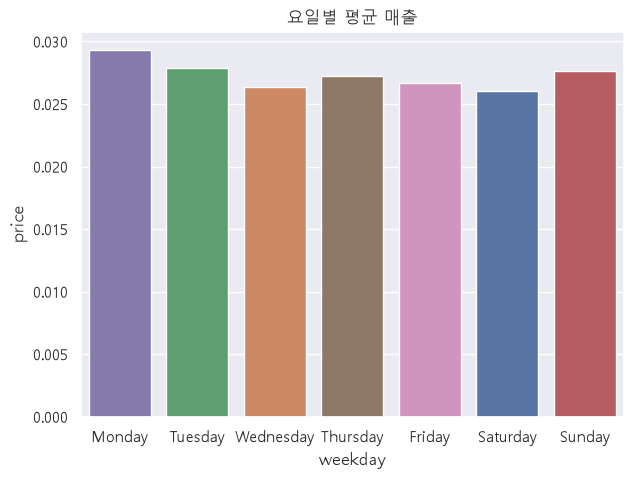

요일별 평균 매출의 막대그래프 시각화 결과를 보면,
'월요일, 화요일, 일요일'의 매출이 다른 요일에 비해 상대적으로 높은 것으로 보인다.


month,1,2,3,4,5,6,7,8,9,10,11,12
weekday,,,,,,,,,,,,
Friday,0.023,0.027,0.026,0.027,0.030,0.025,0.019,0.026,0.030,0.031,0.029,0.027
Monday,0.031,0.031,0.038,0.031,0.030,0.024,0.025,0.020,0.035,0.032,0.032,0.031
Saturday,0.020,0.029,0.029,0.025,0.025,0.025,0.021,0.019,0.032,0.027,0.030,0.026
Sunday,0.025,0.030,0.031,0.028,0.028,0.026,0.023,0.021,0.029,0.031,0.033,0.024
Thursday,0.029,0.025,0.030,0.028,0.027,0.027,0.019,0.027,0.031,0.034,0.027,0.026
Tuesday,0.025,0.030,0.024,0.028,0.031,0.024,0.023,0.025,0.030,0.045,0.032,0.028
Wednesday,0.025,0.025,0.027,0.028,0.031,0.022,0.018,0.027,0.032,0.033,0.031,0.029


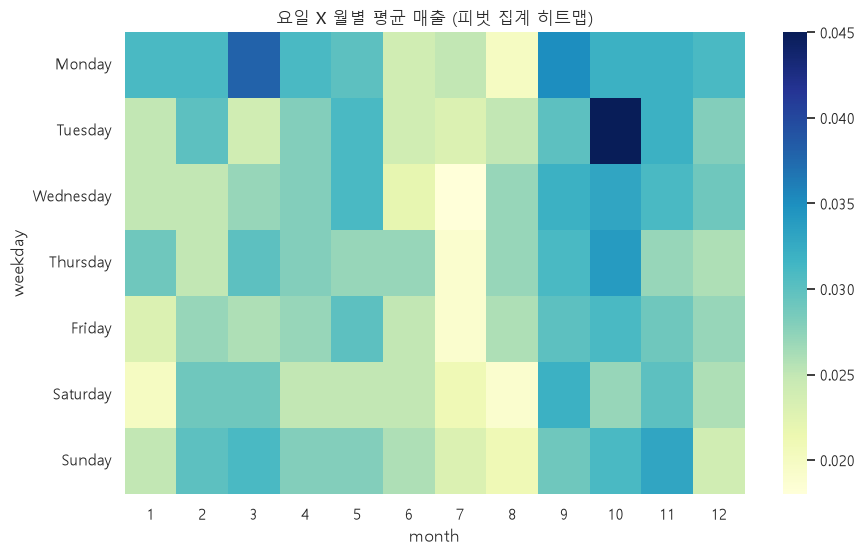

요일/월별 평균 매출의 피벗 테이블 집계 후 히트맵 시각화 결과를 보면,
'월요일, 화요일, 일요일'의 매출이 다른 요일에 비해 상대적으로 높은 것으로 보인다.


month,1,2,3,4,5,6,7,8,9,10,11,12
weekday,,,,,,,,,,,,
Monday,0.031080,0.030699,0.037710,0.031343,0.029844,0.024058,0.025398,0.020205,0.034742,0.031514,0.032480,0.030665
Tuesday,0.024673,0.030157,0.023636,0.027805,0.030966,0.023987,0.023385,0.024889,0.030369,0.044761,0.032017,0.027576
Wednesday,0.024627,0.025368,0.027010,0.027929,0.031354,0.021847,0.017978,0.027132,0.031866,0.032638,0.030936,0.029352
Thursday,0.028969,0.024531,0.030133,0.027911,0.027352,0.026637,0.019326,0.026945,0.031191,0.034281,0.027262,0.025799
Friday,0.023484,0.026647,0.025778,0.026714,0.029542,0.025466,0.018786,0.025847,0.030395,0.031360,0.029028,0.027389
Saturday,0.019846,0.029049,0.028710,0.025210,0.024576,0.024988,0.021293,0.018940,0.031726,0.027495,0.029682,0.026409
Sunday,0.024790,0.030209,0.030603,0.028160,0.028120,0.026375,0.022513,0.020879,0.029496,0.031405,0.032976,0.023806


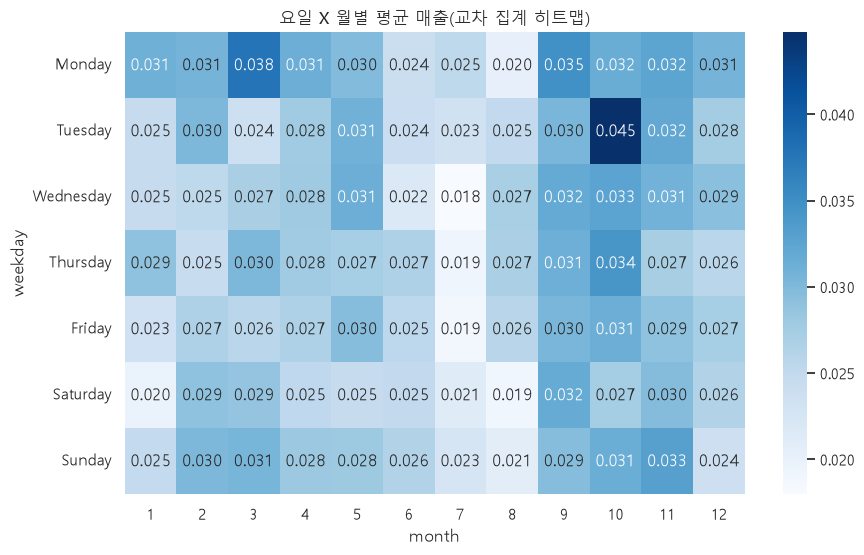

요일/월별 평균 매출의 크로스탭 집계 후 시각화 결과를 보면,
'월요일, 화요일, 일요일'의 매출이 다른 요일에 비해 상대적으로 높은 것으로 보인다.


In [175]:
# 여기에 코드를 작성하세요
# groupby() 로 요일별 평균 매출을 계산하고 소수점 3자리로 표시
grouped = df_s.groupby('weekday')['price'].mean().round(3)
display(grouped)

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 요일별 평균 매출 시각화 - 막대그래프(barplot)
plt.figure(figsize=(7, 5))
ax = sns.barplot(data=df_s, x='weekday', y='price', hue='weekday',order=order, errorbar=None, dodge=False)
ax.set_title('요일별 평균 매출')
plt.show()
print("요일별 평균 매출의 막대그래프 시각화 결과를 보면,\n'월요일, 화요일, 일요일'의 매출이 다른 요일에 비해 상대적으로 높은 것으로 보인다.")

# pivot_table()로 요일/월별 평균 매출을 계산하고 소수점 3자리로 표시
pivot = df_s.pivot_table(index='weekday', columns='month', values='price').round(3)
display(pivot)

# 요일/월별 평균 매출 시각화 - 피벗 테이블(pivot_table) + 히트맵(heatmap)
pivot = pivot.reindex(order)   # 요일 순서를 지정
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=False, cmap='YlGnBu', ax=ax)
ax.set_title('요일 X 월별 평균 매출 (피벗 집계 히트맵)')
plt.show()
print("요일/월별 평균 매출의 피벗 테이블 집계 후 히트맵 시각화 결과를 보면,\n'월요일, 화요일, 일요일'의 매출이 다른 요일에 비해 상대적으로 높은 것으로 보인다.")

# crosstab()로 요일/월별 평균 매출을 계산
ct = pd.crosstab(index=df_s['weekday'], columns=df_s['month'], values=df_s['price'], aggfunc='mean').reindex(order)
display(ct)

# 요일/월별 교차표 시각화 - 히트맵(heatmap)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ct, annot=True, cmap='Blues', fmt='.3f', cbar=True)
ax.set_title('요일 X 월별 평균 매출(교차 집계 히트맵)')
plt.show()
print("요일/월별 평균 매출의 크로스탭 집계 후 시각화 결과를 보면,\n'월요일, 화요일, 일요일'의 매출이 다른 요일에 비해 상대적으로 높은 것으로 보인다.")


## 3. 선택 EDA 미션 카탈로그
> 🔧 **이 절은 선택입니다.** 원하는 것만 골라서 하세요 — 전부 할 필요 없습니다. 각 미션은 **발제문의 심화 분석 목표**를 문제로 만든 것이고, day07·day08 교안의 도구를 응용하면 대부분 시작할 수 있습니다.

| 난이도 | 선택 미션 | 쓰는 도구 | 예상 시간 |
|---|---|---|---|
| ★ | 1. 산점도 등 다양한 형식으로 시각화 | `scatterplot`·`pairplot` | 15분 |
| ★ | 2. 고객 속성 × 채널 교차분석 | `crosstab`·`heatmap` | 15분 |
| ★★ | 3. 로그 변환·정규화(z-score·Min-Max)로 분포 비교 | `np.log`·표준화 계산 | 20분 |
| ★★ | 4. 이상치 고객·거래 탐색 전략 | IQR 규칙·`boxplot` | 20분 |
| ★★ | 5. 월별·분기별 평균 매출 — 추세와 시즌성 | `dt.quarter`·`lineplot` | 20분 |
| ★★ | 6. 채널 비중 해석 보정 — 비율(%)과 ARPU | `nunique`·비율 계산 | 20분 |
| ★★★ | 7. 고객별 총 구매액 상위 20% vs 하위 20% | `qcut`·`groupby` | 25분 |
| ★★★ | 8. 월별 매출의 3개월 롤링 평균 | `rolling().mean()` | 20분 |

> ⚠️ **이 데이터의 기간은 1년(2019-01-01 ~ 2019-12-31)입니다.** 그래서 5·8번은 **"연도별 추세"가 아니라 "1년 안의 월별 흐름"** 까지만 말할 수 있습니다. 발제문에는 "수년간"이라고 적혀 있지만, 여러분의 데이터로 직접 확인한 사실이 우선입니다.

### 선택 미션 1 (★) — 산점도 등 다양한 형식으로 시각화
> 발제문 심화 분석 목표 ①

**비즈니스 질문**: "많이 사는 고객"과 "비싸게 사는 고객"은 같은 사람인가?

- **무엇을 만드나**: **고객 한 명을 점 하나로** 만든 표(구매건수·총구매액·평균구매액)를 준비해 산점도를 그리고, 세 변수를 한 번에 보는 격자 그림(`pairplot`)까지 그립니다. 거래 한 건이 아니라 **고객 한 명**이 관측 단위가 되는 것이 핵심입니다.
- **이렇게 나오면 맞다**: 산점도에서 구매건수가 늘면 총구매액도 대체로 늘지만(우상향), **평균구매액과 구매건수 사이에는 그런 경향이 거의 안 보입니다** — 이 두 그림의 차이를 한 줄로 설명할 수 있으면 성공입니다.
- **함정**: 고객 대부분이 구매 1~2건이라 점이 왼쪽에 뭉칩니다 — `alpha` 로 투명하게 하거나 표본을 쓰세요. `pairplot` 은 그림 단위 함수라 `figsize` 대신 `height` 를 씁니다(수만 행을 그대로 넣으면 매우 느립니다).

In [93]:
# ── 쓸 도구 ─────────────────────────────────────────
#   고객 단위 표: df.groupby('customer_id').agg(…) 로 건수·합계를 구하고, 평균구매액은 두
#     컬럼을 나눠 만듭니다.
#   산점도: sns.scatterplot(data=…, x=…, y=…, alpha=…) — 점이 많으면 <표>.sample(n=…,
#     random_state=42) 로 표본을 씁니다.
#   여러 수치 변수를 한 번에: sns.pairplot(<수치 컬럼만 남긴 표>, height=…) — 대각선은 각
#     변수의 분포, 나머지 칸은 두 변수의 산점도입니다.
#   관계의 세기를 숫자로도 보고 싶으면 상관 도구.

# 여기에 코드를 작성하세요

### 선택 미션 2 (★) — 고객 속성 × 채널 교차분석
> 발제문 심화 분석 목표 ⑦

**비즈니스 질문**: 멤버십 상태나 뉴스 구독 습관에 따라 **주로 쓰는 채널**이 다른가?

- **무엇을 만드나**: 고객 속성(`club_member_status`·`fashion_news_frequency`·`age_group` 중 둘 이상)과 채널의 교차표를 만들고, **행 기준 비율**로 바꿔 히트맵으로 보여줍니다. 비율표와 함께 **건수표도** 제시해 표본이 작은 범주를 드러냅니다.
- **이렇게 나오면 맞다**: 비율표와 건수표를 나란히 놓았을 때, **비중이 극단적으로 보이는 범주가 실은 건수가 아주 적다**는 것을 스스로 지적할 수 있으면 성공입니다. 어떤 속성에서는 범주 간 비중 차이가 거의 없을 수도 있는데, 그 "차이가 없다"도 결론입니다.
- **함정**: 비율만 보면 **50건짜리 범주와 10만 건짜리 범주가 똑같은 크기의 칸**으로 보입니다 — 건수를 함께 보지 않으면 "탈퇴 고객은 96%가 온라인" 같은 문장을 근거 없이 쓰게 됩니다. `fmt='d'` 는 비율표에서 에러가 납니다(`'.2f'` 로).

In [94]:
# ── 쓸 도구 ─────────────────────────────────────────
#   교차표: pd.crosstab(<속성 시리즈>, <채널 시리즈>) — 비율은 normalize='index'.
#   히트맵: sns.heatmap(<비율표>, annot=True, fmt='.2f', cmap='Blues').
#   표본 크기 확인: 비율표와 나란히 normalize 없는 건수표를 함께 출력합니다.

# 여기에 코드를 작성하세요

### 선택 미션 3 (★★) — 로그 변환·정규화(z-score·Min-Max)로 분포 비교
> 발제문 심화 분석 목표 ④

**비즈니스 질문**: 치우친 가격 분포를 **어떻게 손봐야** 고객·상품군끼리 공정하게 비교할 수 있나?

- **무엇을 만드나**: price 에 ① 로그 변환 ② z-score 표준화 ③ Min-Max 정규화를 각각 적용해, **네 가지 버전(원본 포함)의 왜도와 히스토그램**을 비교합니다. 그다음 z-score 를 써서 **상품 대분류별 평균 z** 를 구해 어느 군이 전체 평균보다 비싼지 봅니다.
- **이렇게 나오면 맞다**: **로그 변환만 왜도가 크게 줄고, z-score·Min-Max 는 왜도가 원본과 똑같이 남습니다.** 왜 그런지 한 줄로 설명할 수 있으면 이 미션의 핵심을 얻은 것입니다.
- **함정**: z-score·Min-Max 는 축의 **위치와 크기만 바꾸는 선형 변환**이라 분포 **모양**(치우침)은 그대로입니다 — "정규화하면 정규분포가 된다"는 오해를 여기서 깨야 합니다. `np.log` 는 0 이하에서 무한대·NaN 이 됩니다.

In [95]:
# ── 쓸 도구 ─────────────────────────────────────────
#   로그 변환: np.log(<값>).
#   z-score: 평균을 빼고 표준편차로 나눕니다(.mean()·.std(ddof=1)).
#   Min-Max: 최솟값을 빼고 (최대−최소)로 나눕니다.
#   왜도는 stats.skew(<값>), 그림은 subplots + histplot.
#   군별 비교: 새로 만든 z 값을 컬럼으로 붙여(df.assign(<이름>=…)) groupby(<군>) 으로 평균.

# 여기에 코드를 작성하세요

### 선택 미션 4 (★★) — 이상치 고객·거래 탐색 전략
> 발제문 심화 분석 목표 ⑥

**비즈니스 질문**: "비정상적으로 큰" 거래와 고객을 어떻게 찾고, 찾은 다음 **제거할지 남길지** 어떻게 정하나?

- **무엇을 만드나**: IQR 1.5배 규칙으로 ① **거래 단위** 이상치와 ② **고객 총구매액 단위** 이상치를 각각 찾아, 건수·비율·**그들이 차지하는 매출 비중**을 출력합니다. 그리고 그 이상치를 **제거할지·남길지·따로 표시(플래그)할지**를 근거와 함께 한 줄로 적습니다.
- **이렇게 나오면 맞다**: 이상치 거래는 전체의 **5% 안팎인데 매출은 그보다 훨씬 큰 몫**을 차지합니다 — 그래서 "이상치니까 지운다"가 위험하다는 결론이 데이터에서 나옵니다. 거래 단위와 고객 단위의 결과가 다르다는 것도 확인하세요.
- **함정**: **이상치 = 오류가 아닙니다.** 여기서 잡힌 것은 대부분 정상적인 고가 상품(코트·신발)입니다 — 지우면 매출의 상당 부분이 사라집니다. 그리고 IQR 규칙은 **한쪽으로 치우친 분포에서 상단을 과하게 잡는다**는 한계가 있으니, 로그 변환 후 다시 보거나 상위 1% 같은 다른 기준과 비교해 보세요.

In [96]:
# ── 쓸 도구 ─────────────────────────────────────────
#   IQR 규칙: .quantile([0.25, 0.75]) 로 Q1·Q3 -> IQR -> 상한은 Q3 + 1.5 × IQR.
#   이상치만 고르기: 불리언 조건으로 필터 — 비율은 조건의 .mean(), 건수는 .sum().
#   고객 단위: df.groupby('customer_id')['price'].sum() 에 같은 규칙을 적용합니다.
#   매출 비중: 이상치의 합 ÷ 전체 합.
#   그림: sns.boxplot(x=<시리즈>) — 상자 밖 점이 이 규칙이 말하는 이상치입니다.
#   어떤 상품군에서 나오는지 보려면 value_counts().head().

# 여기에 코드를 작성하세요

### 선택 미션 5 (★★) — 월별·분기별 평균 매출 — 추세와 시즌성
> 발제문 심화 분석 목표 ⑤

**비즈니스 질문**: 매출이 특정 시기에 몰리는가? 그 급증을 "성장"이라고 불러도 되는가?

- **무엇을 만드나**: 월별·분기별로 **총매출·건수·평균가**를 집계해 표로 만들고, 월별 흐름을 꺾은선으로, 분기별 비교를 막대로 그립니다. 그리고 **급증한 달이 건수 때문인지 단가 때문인지** 구분해 한 줄로 적습니다.
- **이렇게 나오면 맞다**: 총매출이 가장 큰 달과 평균가가 가장 큰 달이 **서로 다릅니다** — 그래서 "매출이 늘었다"를 **건수 증가**와 **단가 상승**으로 쪼개 설명할 수 있으면 성공입니다.
- **함정**: 이 데이터는 **1년뿐**이라 "증가 추세/감소 추세" 같은 장기 판단을 할 수 없습니다(작년 같은 달과 비교할 수 없으므로). 시즌 이벤트(블랙프라이데이·연말연시)로 인한 급증을 성장으로 단정하지 말라는 발제문 경고가 바로 이 지점입니다.

In [97]:
# ── 쓸 도구 ─────────────────────────────────────────
#   분기 파생: 날짜형 컬럼의 .dt.quarter (1~4).
#   집계: groupby(<월 또는 분기>).agg(…) 로 합계·건수·평균을 한 표에.
#   그림: lineplot(추이) + barplot(분기 비교). 집계 결과는 reset_index() 후 넣습니다.
#   최대·최소 달 찾기: .idxmax()·.idxmin().

# 여기에 코드를 작성하세요

### 선택 미션 6 (★★) — 채널 비중 해석 보정 — 비율(%)과 ARPU
> 발제문 심화 분석 목표 FAQ(표본 크기 차이 보정)

**비즈니스 질문**: 온라인이 오프라인보다 매출이 크다는 말은, 온라인 **기록이 더 많아서** 생긴 착시가 아닐까?

- **무엇을 만드나**: 채널별로 **건수·총매출·고객 수**를 구하고, 여기서 ① 건수 비중(%) ② 매출 비중(%) ③ **ARPU(고객당 평균 구매액)** ④ 고객당 구매 건수 ⑤ 거래당 평균가를 계산한 표를 만듭니다. 그리고 **표본 크기 차이를 보정한 뒤에도 결론이 유지되는지** 한 줄로 적습니다.
- **이렇게 나오면 맞다**: 채널별 ARPU 와 거래당 평균가를 나란히 놓았을 때, **"온라인 우세"가 단순히 기록 수 차이 때문이 아니라는 것(또는 그 반대)** 을 근거를 들어 말할 수 있으면 성공입니다.
- **함정**: **채널별 고객 수를 더하면 전체 고객 수보다 많습니다** — 두 채널을 모두 쓴 고객이 양쪽에 세어지기 때문입니다(그래서 ARPU 는 채널별로만 비교하고 합산하지 마세요). 그리고 이 데이터는 애초에 온라인 기록이 더 많이 수집된 표본이라, 보정 후에도 **"시장 전체에서 온라인이 우세하다"로 일반화할 수는 없습니다.**

In [98]:
# ── 쓸 도구 ─────────────────────────────────────────
#   고객 수는 중복을 뺀 개수 — agg(<이름>=('customer_id', 'nunique')).
#   비중: 각 값을 <컬럼>.sum() 으로 나눕니다.
#   ARPU = 총매출 ÷ 고객 수, 고객당 건수 = 건수 ÷ 고객 수, 거래당 평균가 = 총매출 ÷ 건수.
#   두 채널을 모두 쓴 고객 수: df.groupby('customer_id')['sales_channel_id'].nunique() 가 2
#     인 고객을 셉니다.

# 여기에 코드를 작성하세요

### 선택 미션 7 (★★★) — 고객별 총 구매액 상위 20% vs 하위 20%
> 발제문 심화 분석 목표 ②

**비즈니스 질문**: 우리 매출은 소수의 고객에게 얼마나 몰려 있고, 그 고객들은 무엇이 다른가?

- **무엇을 만드나**: 고객별 **총구매액·구매건수·평균구매액·온라인 비중**을 만든 뒤 총구매액으로 **5분위**로 나눠, **상위 20%와 하위 20%** 의 지표를 비교하는 표와 그림을 만듭니다. 두 그룹이 **전체 매출에서 차지하는 비중**도 함께 계산합니다.
- **이렇게 나오면 맞다**: 상위 20% 가 전체 매출의 **40% 이상**을 차지하고, 하위 20% 는 10% 미만입니다. 그리고 상위 그룹은 평균구매액·구매건수·온라인 비중이 **모두** 더 높게 나옵니다 — 세 지표 중 어느 것이 가장 크게 벌어지는지 말할 수 있으면 성공입니다.
- **함정**: `qcut` 은 **같은 개수**로 나누므로, 총구매액이 같은 고객이 많으면 경계가 딱 20%가 아닐 수 있습니다. 그리고 이 5분위는 **총구매액으로 만든 것**이라 "상위 20%가 총구매액이 크다"는 것은 동어반복입니다 — 의미 있는 발견은 **평균구매액·건수·채널처럼 나누는 데 쓰지 않은 지표**에서 나옵니다.

In [99]:
# ── 쓸 도구 ─────────────────────────────────────────
#   고객 단위 표: df.groupby('customer_id').agg(…) — 온라인 비중은 "채널이 2인가"라는
#     참/거짓 컬럼의 평균으로 구할 수 있습니다(df.assign(<이름>=<조건>) 으로 먼저 컬럼을
#     만들면 편합니다).
#   5분위 나누기: pd.qcut(<시리즈>, q=5, labels=[…]) — 같은 개수로 나눕니다(pd.cut 은 같은
#     폭으로 나눔).
#   그룹 비교: groupby(<그룹 컬럼>, observed=True)[<지표들>].mean().
#   매출 점유율: 그룹별 합계 ÷ 전체 합계.
#   그림: barplot 으로 그룹별 지표 비교.

# 여기에 코드를 작성하세요

### 선택 미션 8 (★★★) — 월별 매출의 3개월 롤링 평균
> 발제문 심화 분석 목표 ③

**비즈니스 질문**: 월별 매출이 들쭉날쭉할 때, **노이즈를 걷어낸 흐름**은 어떤 모양인가?

- **무엇을 만드나**: 월별 총매출 표를 만들고 **3개월 롤링 평균** 컬럼을 추가해, 원래 선과 롤링 선을 **한 그림에 겹쳐** 그립니다. 앞의 두 달이 왜 비어 있는지, 롤링 창을 6개월로 늘리면 무엇이 달라지는지도 한 줄로 적습니다.
- **이렇게 나오면 맞다**: 롤링 선이 원래 선보다 **매끄럽고**, 1·2월 자리는 값이 없어 선이 3월부터 시작합니다. 두 선이 어긋나는 달을 짚어 "그 달만 튀었다"고 말할 수 있으면 성공입니다.
- **함정**: 롤링 평균은 **창 크기−1 개월만큼 뒤로 늦게 반응**합니다(그래서 앞부분이 NaN). 우리 데이터는 12개월뿐이라 6개월 창을 쓰면 점이 7개만 남아 추세라고 부르기 어렵습니다 — **3개월 창이 이 데이터에 맞는 선택**입니다. 그리고 월별 합계는 **그 달의 일수·표본 수**에 영향을 받으니, 필요하면 평균가와 함께 보세요.

In [100]:
# ── 쓸 도구 ─────────────────────────────────────────
#   월별 집계: df.groupby('month')['price'].sum() — 그래프에 넣으려면
#     reset_index(name=<이름>).
#   롤링 평균: <시리즈>.rolling(<창 크기>).mean() — 창 크기 3 이면 3개월 이동 평균.
#   겹쳐 그리기: plt.plot(<x>, <y>, label=…) 을 두 번 부르고 plt.legend().
#   월 눈금 고정: plt.xticks(range(1, 13)).

# 여기에 코드를 작성하세요

## 4. 관찰 정리 (서술)
**이 절에서 할 일**: 위에서 본 집계·그래프를 근거로 **한 문단짜리 인사이트**를 씁니다. "A 이다" 로 끝내지 말고, **다른 설명 가능성**(다른 변수가 진짜 원인일 수도 있다는 점)도 함께 짚으세요 — 관찰연구는 상관이지 인과가 아닙니다.

**쓰는 순서**: ① 어떤 집계·그래프를 봤나 → ② 거기서 무엇을 관찰했나 → ③ 다른 설명 가능성은 없는가 → ④ 우연인지 검정으로 확인하고 싶은 질문.

- 어떤 축(연령대·채널·상품군 등)에서 가장 뚜렷한 차이를 봤나요?
- 그 차이가 우연이 아니라고 자신 있게 말할 수 있나요, 아니면 검정으로 확인하고 싶은가요?
- 표본 크기가 작은 범주나, 온라인에 치우친 이 데이터의 한계를 함께 적었나요?

*(여기에 관찰과, 다른 설명 가능성과, 다음 파트로 넘길 질문을 서술하세요)*

> ✅ **여기까지 되면 통과**: 한 문단 서술에 관찰 + 다른 설명 가능성 + 다음 파트로 넘길 질문이 모두 있으면 됩니다.